TEST 1
Independent Sample t-Test

Objective

To determine whether shipment cost differs significantly between Air and Ground transportation.

**Business Problem**

Management believes

Air transportation is more expensive than Ground transportation.

Our dashboards also showed this.

Now we'll verify statistically.

Business Question

Does delivery mode significantly affect shipment cost?

Independent t-Test compares Mean of Group A with Mean of Group B

Here

Group A

***AIR***

Group B

***GROUND***

Variable

***Shipment Cost***

Exactly fits an Independent Sample t-Test.

**Hypothesis**

***Null Hypothesis (H₀)***

There is no significant difference in average shipment cost between Air and Ground deliveries.

**Mathematically**

μAir = μGround

***Alternative Hypothesis (H₁)***

There is a significant difference in average shipment cost between Air and Ground deliveries.

μAir ≠ μGround

**Significance Level**

α = 0.05

Meaning
If
p-value < **0.05**

Reject ***H₀***

Otherwise

Accept ***H₀***

In [27]:
# import libraries
import pandas as pd
import numpy as np

from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# load dataset
shipment = pd.read_csv("ShipmentDelivery_Cleaned.csv")
shipment.head()

,Shipment_ID,Customer,Warehouse_ID,Destination_Region,Dispatch_Date,Delivery_Date,Delivery_Time_Days,Weight,Carrier_Name,Shipment_Status,Delivery_Mode,Shipment_Cost,Delivery_Accuracy_Flag,Damage_Flag
0,S000001,V55555_53,PLANT16,PORT09,2024-12-15,2024-12-18,3,14.30,V44_3,Delivered,AIR,1.4992,1,0
1,S000002,V55555_53,PLANT16,PORT09,2023-03-28,2023-04-01,4,87.94,V44_3,Delivered,AIR,1.4992,1,0
2,S000003,V55555_53,PLANT16,PORT09,2024-01-19,2024-01-24,5,61.20,V44_3,Delivered,AIR,1.4992,1,1
3,S000004,V55555_53,PLANT16,PORT09,2023-10-21,2023-10-26,5,16.16,V44_3,Delivered,AIR,1.4992,1,0
4,S000005,V55555_53,PLANT16,PORT09,2024-07-21,2024-07-24,3,52.34,V44_3,Delivered,AIR,1.4992,1,0


Interpretation:

• Successfully imported the Shipment Delivery dataset.

• The dataset contains shipment information such as delivery mode, shipment cost, carrier, warehouse, and shipment status.

• The dataset is ready for statistical analysis.

In [4]:
# check dataset info
shipment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209402 entries, 0 to 209401
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Shipment_ID             209402 non-null  object 
 1   Customer                209402 non-null  object 
 2   Warehouse_ID            209402 non-null  object 
 3   Destination_Region      209402 non-null  object 
 4   Dispatch_Date           209402 non-null  object 
 5   Delivery_Date           209402 non-null  object 
 6   Delivery_Time_Days      209402 non-null  int64  
 7   Weight                  209402 non-null  float64
 8   Carrier_Name            209402 non-null  object 
 9   Shipment_Status         209402 non-null  object 
 10  Delivery_Mode           209402 non-null  object 
 11  Shipment_Cost           209402 non-null  float64
 12  Delivery_Accuracy_Flag  209402 non-null  int64  
 13  Damage_Flag             209402 non-null  int64  
dtypes: float64(2), int64

In [5]:
# checking missing values
shipment.isnull().sum()

,0
Shipment_ID,0
Customer,0
Warehouse_ID,0
Destination_Region,0
Dispatch_Date,0
Delivery_Date,0
Delivery_Time_Days,0
Weight,0
Carrier_Name,0
Shipment_Status,0


In [22]:
# Separate Air and Ground Shipments

air = shipment[shipment["Delivery_Mode"]=="AIR   "]["Shipment_Cost"]

ground = shipment[shipment["Delivery_Mode"]=="GROUND"]["Shipment_Cost"]


In [23]:
print("Air Shipments :", len(air))
print("Ground Shipments :", len(ground))

Air Shipments : 209334
Ground Shipments : 68


In [24]:
# calculate mean
print("Average Air Shipment Cost :", air.mean())

print("Average Ground Shipment Cost :", ground.mean())

Average Air Shipment Cost : 9.678685441088204
Average Ground Shipment Cost : 1711.2840470198676


In [25]:
# perform indepentant t test
t_stat, p_value = ttest_ind(air, ground)

print("T Statistic :", t_stat)

print("P Value :", p_value)

T Statistic : -143.08581106431762
P Value : 0.0


In [26]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
    print("Delivery Mode significantly affects Shipment Cost")
else:
    print("Fail to Reject Null Hypothesis")
    print("No significant difference in Shipment Cost")

Reject Null Hypothesis
Delivery Mode significantly affects Shipment Cost


**Interpretation:**

-The dataset contains 209,334 Air shipments and 68 Ground shipments.

-The average shipment cost for Air deliveries is 9.68, whereas the average shipment cost for Ground deliveries is 1711.28.

-The calculated t-statistic is -143.09, indicating a substantial difference between the average shipment costs of the two delivery modes.

-The obtained p-value is 0.0000, which is significantly lower than the chosen significance level (α = 0.05).

-Since the p-value is less than 0.05, the Null Hypothesis is rejected.

-This confirms that Delivery Mode has a statistically significant effect on Shipment Cost.

-The analysis indicates that shipment costs differ considerably between Air and Ground transportation in the available logistics dataset.

-Although Ground shipments are fewer in number, they exhibit substantially higher average shipment costs, suggesting that Ground transportation in this dataset is primarily associated with high-cost shipments.

**Business Insights:**

-Delivery mode is a major contributor to shipment cost variation.

-Ground deliveries, although limited in number, account for significantly higher average shipment costs.

-Air transportation represents the majority of shipments in the logistics network.

-Cost optimization strategies should evaluate when high-cost Ground transportation is necessary and whether alternative routing or transportation methods can reduce expenses.

-These findings support better budgeting, transportation planning, and carrier selection decisions.

**Test 2: Pearson Correlation**

To determine whether a statistically significant linear relationship exists between warehouse utilization and operational cost using the Pearson Correlation Coefficient.



Pearson Correlation is used when:

Both variables are numerical.
We want to measure the strength and direction of a linear relationship.
The coefficient (r) ranges from -1 to +1

**Hypothesis**

*Null Hypothesis (H₀)*

There is no significant relationship between Warehouse Utilization and Operational Cost.

*Alternative Hypothesis (H₁)*

There is a significant relationship between Warehouse Utilization and Operational Cost.

In [28]:
# load dataset
warehouse = pd.read_csv("WarehouseOperations_Cleaned.csv")
warehouse.head()

,Warehouse_ID,Warehouse_Capacity_Units,Current_Inventory_Units,Inventory_Turnover_Ratio,Order_Fulfilment_Rate,Avg_Pick_Pack_Time_Min,Warehouse_Utilization_Percentage,Labour_Hours_Per_Day,Operational_Cost_Per_Day
0,PLANT15,246,149,2.81904,100.0,22,60.57,3,42.17
1,PLANT17,179,112,2.81904,100.0,24,62.57,3,9.61
2,PLANT18,2488,2041,2.81904,100.0,24,82.03,4,831.20
3,PLANT05,8631,6252,2.81904,100.0,23,72.44,12,610.38
4,PLANT02,3094,1780,2.81904,100.0,25,57.53,3,169.99


In [29]:
# Check column name
warehouse.columns

Index(['Warehouse_ID', 'Warehouse_Capacity_Units', 'Current_Inventory_Units',
       'Inventory_Turnover_Ratio', 'Order_Fulfilment_Rate',
       'Avg_Pick_Pack_Time_Min', 'Warehouse_Utilization_Percentage',
       'Labour_Hours_Per_Day', 'Operational_Cost_Per_Day'],
      dtype='object')

In [30]:
# Select variables
x = warehouse["Warehouse_Utilization_Percentage"]
y = warehouse["Operational_Cost_Per_Day"]

In [31]:
from scipy.stats import pearsonr

r, p_value = pearsonr(x, y)

print("Correlation Coefficient (r):", r)
print("P-value:", p_value)

Correlation Coefficient (r): -0.31289278557774414
P-value: 0.19212479717094055


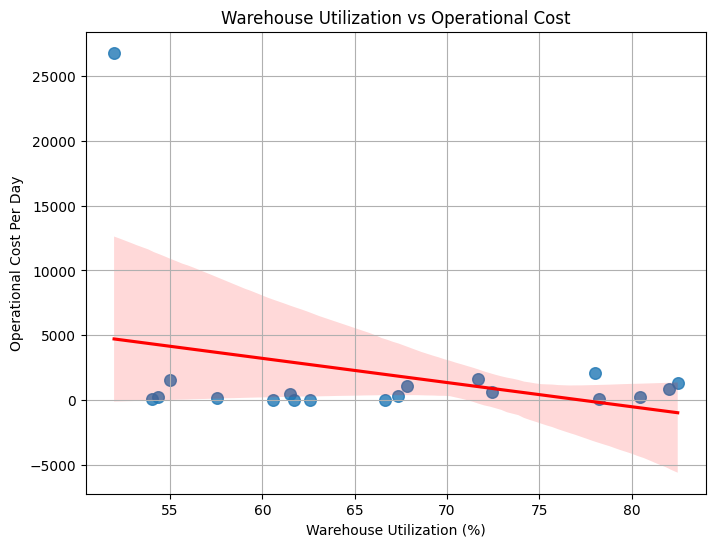

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.regplot(
    x=x,
    y=y,
    scatter_kws={"s":70},
    line_kws={"color":"red"}
)

plt.title("Warehouse Utilization vs Operational Cost")
plt.xlabel("Warehouse Utilization (%)")
plt.ylabel("Operational Cost Per Day")

plt.grid(True)

plt.show()

In [33]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
    print("Warehouse Utilization is significantly related to Operational Cost")
else:
    print("Fail to Reject Null Hypothesis")
    print("No significant relationship exists")

Fail to Reject Null Hypothesis
No significant relationship exists


**Interpretation:**

-The calculated Pearson Correlation Coefficient (r = -0.313) indicates a weak negative relationship between Warehouse Utilization Percentage and Operational Cost Per Day.

-This means that as warehouse utilization increases, operational cost shows a slight tendency to decrease; however, the relationship is weak.

-The obtained p-value (0.1921) is greater than the significance level of 0.05.

-Since the p-value exceeds the significance level, the Null Hypothesis cannot be rejected.

-Therefore, the observed negative relationship is not statistically significant.

-Based on the available warehouse data, there is insufficient statistical evidence to conclude that warehouse utilization directly influences operational cost.

-The scatter plot further supports this finding by showing a widely dispersed distribution of data points with only a slight downward regression trend.

**Business Insights:**

-Warehouse utilization alone is not a reliable predictor of operational cost.

-Warehouses operating at higher utilization levels do not necessarily incur higher operational expenses.

-Other operational variables should be analyzed to better understand cost behavior.

-Cost optimization initiatives should consider multiple operational factors rather than focusing solely on utilization.

-Additional predictive models or multivariable analyses may provide deeper insights into operational cost drivers.

**Test 3 – One-Way ANOVA**

**Objective**

To determine whether the average shipment cost differs significantly among different carriers using One-Way ANOVA.

In Test 1, we compared 2 groups (Air vs Ground) using a t-test.

Now we have more than two groups (multiple carriers such as V444_1, V444_0, V44_3, etc.), so ANOVA is the appropriate statistical test.

**Hypotheses**

*Null Hypothesis (H₀)*

There is no significant difference in average shipment cost among different carriers.

μ1=μ2=μ3=⋯


*Alternative Hypothesis (H₁)*

At least one carrier has a significantly different average shipment cost.

In [34]:
# check carrier names
shipment["Carrier_Name"].value_counts()

,count
Carrier_Name,
V444_0,124668
V444_1,83880
V44_3,854


In [35]:
# count number of carriers
shipment["Carrier_Name"].nunique()

3

In [36]:
# seperate shipment cost by carrier
groups = []

for carrier in shipment["Carrier_Name"].unique():
    groups.append(
        shipment[shipment["Carrier_Name"] == carrier]["Shipment_Cost"]
    )

print("Number of Carrier Groups:", len(groups))

Number of Carrier Groups: 3


In [37]:
# Perform One-Way ANOVA

from scipy.stats import f_oneway

f_stat, p_value = f_oneway(*groups)

print("F Statistic :", f_stat)
print("P Value :", p_value)

F Statistic : 756.9614421764179
P Value : 0.0


In [38]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
    print("Carrier Name significantly affects Shipment Cost")
else:
    print("Fail to Reject Null Hypothesis")
    print("No significant difference between carrier shipment costs")

Reject Null Hypothesis
Carrier Name significantly affects Shipment Cost


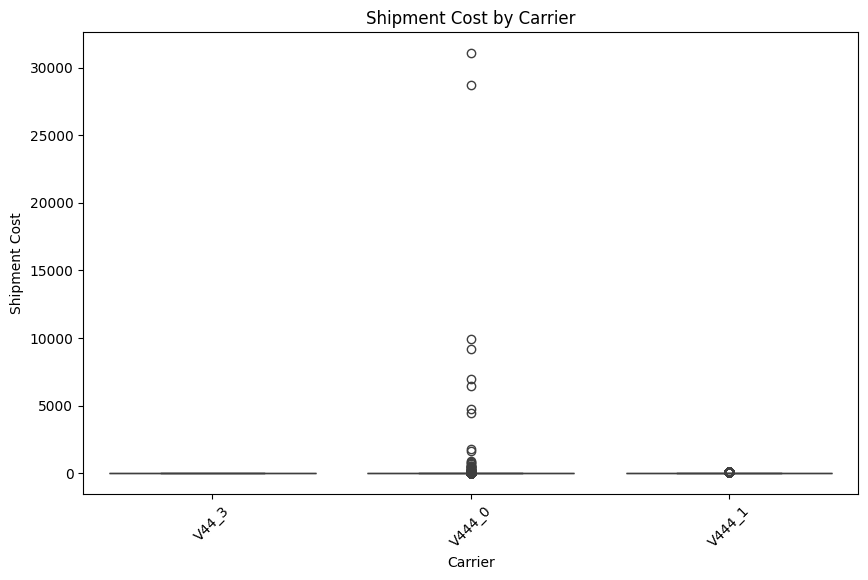

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.boxplot(
    data=shipment,
    x="Carrier_Name",
    y="Shipment_Cost"
)

plt.title("Shipment Cost by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Shipment Cost")

plt.xticks(rotation=45)

plt.show()

**Interpretation:**

-The shipment dataset contains three carrier groups: V444_0, V444_1, and V44_3.

-The calculated F-statistic of 756.96 is extremely high, indicating substantial differences in shipment costs among the carriers.

-The p-value of 0.0000 is significantly lower than the significance level of 0.05.

-Since the p-value is less than 0.05, the Null Hypothesis is rejected.

-Therefore, there is strong statistical evidence that average shipment costs differ significantly among the carriers.

-The boxplot supports this finding by showing noticeable variation in shipment cost distributions across carriers.

-Carrier V444_0 exhibits the widest spread of shipment costs and contains several high-cost shipments, suggesting that this carrier handles shipments with greater cost variability.

-The differences observed indicate that carrier selection has a measurable impact on transportation expenses.

**Business Insights:**

-Shipment cost varies significantly among logistics carriers.

-Carrier V444_0 shows the highest variability in shipment costs and includes several extremely expensive shipments.

-Reviewing carrier pricing structures and shipment allocation strategies can help reduce transportation expenses.

-High-cost shipments should be investigated to identify potential opportunities for route optimization or contract renegotiation.

-Periodic carrier performance analysis can support better procurement and logistics decisions.

Test 4: Chi-Square Test of Independence

**Objective**

To determine whether there is a statistically significant association between Delivery Mode and Shipment Status using the Chi-Square Test of Independence.

The Chi-Square Test is used when:

Both variables are categorical.
We want to determine whether the variables are associated or independent.

In our dataset:

Delivery_Mode → AIR, GROUND
Shipment_Status → Delivered, Delayed

Both are categorical variables, making the Chi-Square Test the correct choice.

**Hypotheses**

***Null Hypothesis (H₀)***

Delivery Mode and Shipment Status are independent.

(Delivery Mode does not affect Shipment Status.)



***Alternative Hypothesis (H₁)***

Delivery Mode and Shipment Status are associated.

(Delivery Mode influences Shipment Status.)

In [40]:
# check categories
print(shipment["Delivery_Mode"].value_counts())

print("---------------------")

print(shipment["Shipment_Status"].value_counts())

Delivery_Mode
AIR       209334
GROUND        68
Name: count, dtype: int64
---------------------
Shipment_Status
Delivered    205382
Delayed        4020
Name: count, dtype: int64


In [41]:
contingency_table = pd.crosstab(
    shipment["Delivery_Mode"],
    shipment["Shipment_Status"]
)

print(contingency_table)

Shipment_Status  Delayed  Delivered
Delivery_Mode                      
AIR                 4020     205314
GROUND                 0         68


In [42]:
# perform chi-Square test
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic :", chi2)
print("P-value :", p_value)
print("Degrees of Freedom :", dof)

Chi-Square Statistic : 0.5068305102891284
P-value : 0.47651413221957073
Degrees of Freedom : 1


In [43]:
# decision
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
    print("Shipment Status is associated with Delivery Mode")
else:
    print("Fail to Reject Null Hypothesis")
    print("Shipment Status is independent of Delivery Mode")

Fail to Reject Null Hypothesis
Shipment Status is independent of Delivery Mode


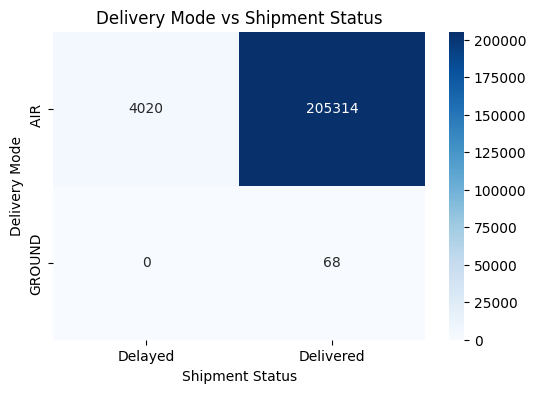

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    contingency_table,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Delivery Mode vs Shipment Status")
plt.xlabel("Shipment Status")
plt.ylabel("Delivery Mode")

plt.show()

**Statistical Interpretation:**

The Chi-Square Test was conducted to determine whether Delivery Mode and Shipment Status are associated.

The obtained Chi-Square statistic (χ² = 0.5068) with a p-value of 0.4765 is greater than the significance level (α = 0.05).

Therefore, the null hypothesis is not rejected.

This indicates that there is no statistically significant association between Delivery Mode and Shipment Status.

**Business Interpretation:**

Shipment delays occur across both delivery modes.

Choosing Air or Ground transportation does not significantly affect whether a shipment is delivered on time.

Delivery performance appears to depend on operational factors other than transportation mode, such as warehouse processing, routing efficiency, weather conditions, or carrier operations.

Improvements in logistics should focus on process optimization rather than simply changing the transportation mode.

**Business Insight**

Although Air transportation dominates shipment volume, statistical testing confirms that delivery mode is not a major factor influencing shipment status.

Management should instead investigate:

-Warehouse processing efficiency

-Route planning

-Carrier performance

-Inventory availability

-Dispatch scheduling

to improve delivery performance.

**Recommendation**

Continue selecting transportation mode based on cost and delivery requirements rather than assuming Air transportation guarantees better delivery performance.

Improve warehouse coordination and dispatch planning.

Monitor carrier service quality to reduce shipment delays.

Use predictive analytics to identify operational causes of delayed shipments.